In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format

In [ ]:
qSales = pd.read_csv('qSales_2024.csv')

display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [ ]:
target_sales = qSales.loc[qSales['tic']=='TGT']

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


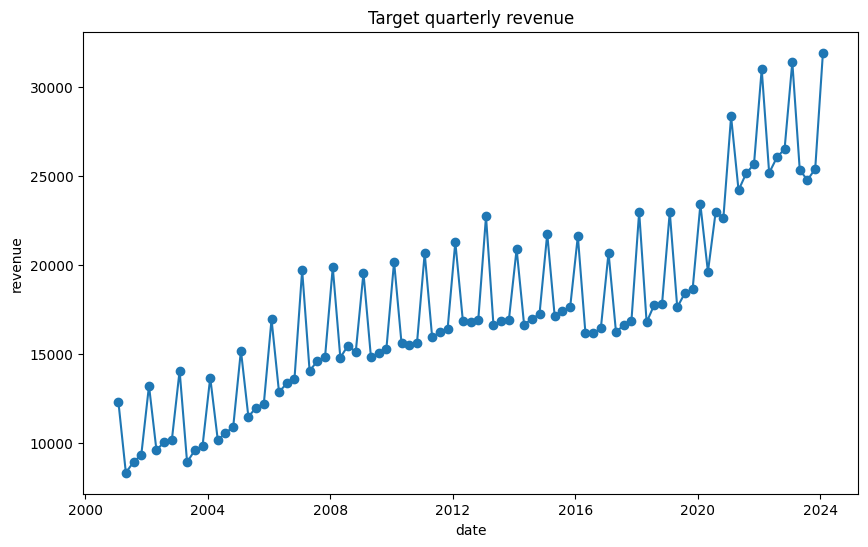

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Target quarterly revenue')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'],target_sales['saleq'],marker='o')

In [ ]:
target_sales['time'] = range(1, len(target_sales) + 1)

display(target_sales)

/tmp/ipykernel_711/1685311324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales) + 1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
target_sales['q4_dv']= np.where(target_sales['fqtr']==4,1,0)
target_sales['q4_interaction'] = target_sales['q4_dv'] * target_sales['time']

target_sales['q1_dv']= np.where(target_sales['fqtr']==1,1,0)
target_sales['q1_interaction'] = target_sales['q1_dv'] * target_sales['time']

display(target_sales)

/tmp/ipykernel_711/1181426834.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['q4_dv']= np.where(target_sales['fqtr']==4,1,0)
/tmp/ipykernel_711/1181426834.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['q4_interaction'] = target_sales['q4_dv'] * target_sales['time']
/tmp/ipykernel_711/1181426834.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,time,q4_dv,q4_interaction,q1_dv,q1_interaction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,...,USD,2000Q4,2000Q4,12324.00,A,1,1,1,0,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,...,USD,2001Q1,2001Q1,8334.00,A,2,0,0,1,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,...,USD,2001Q2,2001Q2,8941.00,A,3,0,0,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,...,USD,2001Q3,2001Q3,9331.00,A,4,0,0,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,...,USD,2001Q4,2001Q4,13220.00,A,5,1,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,...,USD,2022Q4,2022Q4,31395.00,A,89,1,89,0,0
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,...,USD,2023Q1,2023Q1,25322.00,A,90,0,0,1,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,...,USD,2023Q2,2023Q2,24773.00,A,91,0,0,0,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,...,USD,2023Q3,2023Q3,25398.00,A,92,0,0,0,0


In [ ]:
# this is how to take 75% and 25% of the dataset

dt4training = target_sales[:int(0.75 * len(target_sales))] #takes the first 75% of rows
dt4testing = target_sales[int(0.75 * len(target_sales)):] #takes the last 25% of rows

display(dt4training)
display(dt4testing)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,time,q4_dv,q4_interaction,q1_dv,q1_interaction
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,...,USD,2000Q4,2000Q4,12324.00,A,1,1,1,0,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,...,USD,2001Q1,2001Q1,8334.00,A,2,0,0,1,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,...,USD,2001Q2,2001Q2,8941.00,A,3,0,0,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,...,USD,2001Q3,2001Q3,9331.00,A,4,0,0,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,...,USD,2001Q4,2001Q4,13220.00,A,5,1,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,3813,2017-01-31,2016,4,1,INDL,C,D,STD,TGT,...,USD,2016Q4,2016Q4,20690.00,A,65,1,65,0,0
157,3813,2017-04-30,2017,1,1,INDL,C,D,STD,TGT,...,USD,2017Q1,2017Q1,16223.00,A,66,0,0,1,66
158,3813,2017-07-31,2017,2,1,INDL,C,D,STD,TGT,...,USD,2017Q2,2017Q2,16634.00,A,67,0,0,0,0
159,3813,2017-10-31,2017,3,1,INDL,C,D,STD,TGT,...,USD,2017Q3,2017Q3,16874.00,A,68,0,0,0,0


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,curcdq,datacqtr,datafqtr,saleq,costat,time,q4_dv,q4_interaction,q1_dv,q1_interaction
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,USD,2018Q1,2018Q1,16781.00,A,70,0,0,1,70
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,USD,2018Q2,2018Q2,17777.00,A,71,0,0,0,0
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,USD,2018Q3,2018Q3,17821.00,A,72,0,0,0,0
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,USD,2018Q4,2018Q4,22977.00,A,73,1,73,0,0
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,USD,2019Q1,2019Q1,17627.00,A,74,0,0,1,74
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,USD,2019Q2,2019Q2,18422.00,A,75,0,0,0,0
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,USD,2019Q3,2019Q3,18664.00,A,76,0,0,0,0
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,USD,2019Q4,2019Q4,23399.00,A,77,1,77,0,0
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,USD,2020Q1,2020Q1,19615.00,A,78,0,0,1,78
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,USD,2020Q2,2020Q2,22975.00,A,79,0,0,0,0


In [ ]:
y = dt4training.loc[:,'saleq']
x = dt4training.loc[:,['time','q4_dv','q1_dv']]

x = sm.add_constant(x)

model1 = sm.OLS(y,x).fit()

model1.params

,0
const,9399.40
time,139.15
q4_dv,4472.62
q1_dv,-232.80


In [ ]:
x_test = dt4testing.loc[:,['time','q4_dv','q1_dv']]
x_test = sm.add_constant(x_test)
model1_assessment = dt4testing.copy()
model1_assessment['model1_predicted_saleq'] = model1.predict(x_test)
model1_assessment['model1_abs_pct_error'] = abs(
    (
        model1_assessment['saleq'] - model1_assessment['model1_predicted_saleq']
        )/model1_assessment['saleq']
    )

display(model1_assessment)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,...,datafqtr,saleq,costat,time,q4_dv,q4_interaction,q1_dv,q1_interaction,model1_predicted_saleq,model1_abs_pct_error
161,3813,2018-04-30,2018,1,1,INDL,C,D,STD,TGT,...,2018Q1,16781.00,A,70,0,0,1,70,18907.24,0.13
162,3813,2018-07-31,2018,2,1,INDL,C,D,STD,TGT,...,2018Q2,17777.00,A,71,0,0,0,0,19279.19,0.08
163,3813,2018-10-31,2018,3,1,INDL,C,D,STD,TGT,...,2018Q3,17821.00,A,72,0,0,0,0,19418.34,0.09
164,3813,2019-01-31,2018,4,1,INDL,C,D,STD,TGT,...,2018Q4,22977.00,A,73,1,73,0,0,24030.11,0.05
165,3813,2019-04-30,2019,1,1,INDL,C,D,STD,TGT,...,2019Q1,17627.00,A,74,0,0,1,74,19463.85,0.10
166,3813,2019-07-31,2019,2,1,INDL,C,D,STD,TGT,...,2019Q2,18422.00,A,75,0,0,0,0,19835.80,0.08
167,3813,2019-10-31,2019,3,1,INDL,C,D,STD,TGT,...,2019Q3,18664.00,A,76,0,0,0,0,19974.95,0.07
168,3813,2020-01-31,2019,4,1,INDL,C,D,STD,TGT,...,2019Q4,23399.00,A,77,1,77,0,0,24586.72,0.05
169,3813,2020-04-30,2020,1,1,INDL,C,D,STD,TGT,...,2020Q1,19615.00,A,78,0,0,1,78,20020.46,0.02
170,3813,2020-07-31,2020,2,1,INDL,C,D,STD,TGT,...,2020Q2,22975.00,A,79,0,0,0,0,20392.41,0.11


In [ ]:
model1_assessment['model1_abs_pct_error'].mean()

np.float64(0.11973057147230126)

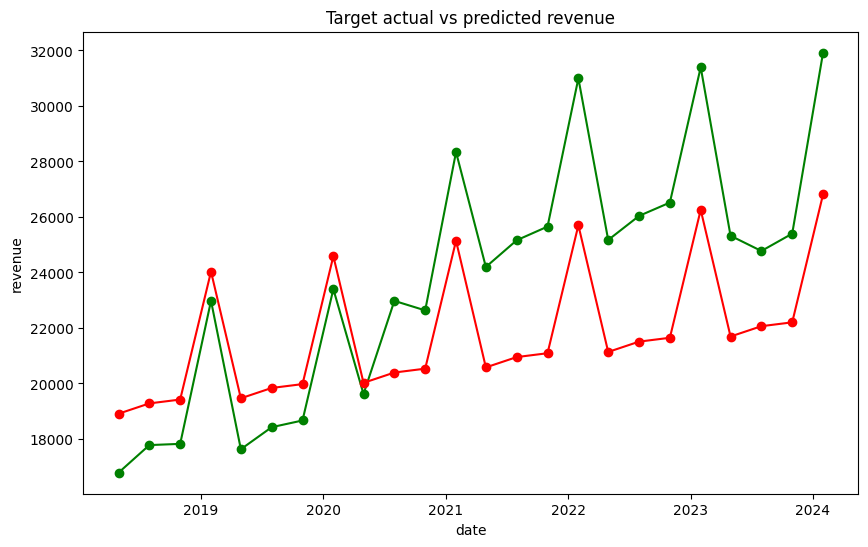

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Target actual vs predicted revenue')
plt.ylabel('revenue')
plt.xlabel('date')

plt.plot(model1_assessment['datadate'],model1_assessment['saleq'],marker='o', color = 'green')
plt.plot(model1_assessment['datadate'],model1_assessment['model1_predicted_saleq'],marker='o', color = 'red')

In this analysis, the model was built using two dummy varaibles. Firstly, the Q1 variable captures the dip in revenue post holidays, and the q4 varaible captures revenue during the holidays. Overall, the model has a mape of about 12%, therefore it is fairly successful in capturing the overall revenue trend for target. Specifically it spikes up during q4 and dips during q1, and this pattern is consistent throughout all the years. One flaw I would say is that in the later says, the prediction is sligtly lower on the revenue scale because recent revenue grew faster than expected. The key insight from Targets revenue is that it is extremely dependent on the season, making it even more predictable. Since Q4 has the highest amount of revenue, it can used as a clear benchmark for overall company performance. Additionally, the model also shows us that there has been steady growth over the years, showing positive investment signs.